<a href="https://www.kaggle.com/code/filippignatov/biosignal-decoding-pain-with-group-aware-ml?scriptVersionId=305960816" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🧠 Pain Prediction: Emphatica E4 Sensor Fusion

**Goal**: Predict pain_scale (Regression) using physiological signals.

**Key Strategy**: Group-based validation to ensure the model generalizes to new humans.

# 1. Setup & Configuration
We define our environment with a focus on reproducibility and efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import warnings

# Global Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

DATA_PATH = '/kaggle/input/datasets/devashishmani1/pain-prediction-dataset-emphatica-e4/pain_dataset_200P_4hz.csv'
TARGET = 'pain_scale'
GROUP_COL = 'person_ID' # Crucial for avoiding leakage
SEED = 42

# 2. The Data Pipeline (Feature Engineering)
Physiological data is noisy. We don't just use raw values; we extract the signal from the noise.

In [2]:
def reduce_mem_usage(df):
    """ Iterate through all columns and modify data types to reduce memory footprint. """
    for col in df.columns:
        if df[col].dtype == 'float64': df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
    return df

def build_advanced_features(df):
    """ 
    Engineering features based on medical signal processing principles.
    """
    raw_sensors = ['eda', 'bvp', 'temp', 'hr', 'acc_x', 'acc_y', 'acc_z']
    
    # 1. Group-Based Normalization (The 'Baseline' Correction)
    # Physiological responses are relative to the individual's rest state.
    for feat in raw_sensors:
        df[f'{feat}_z'] = df.groupby(GROUP_COL)[feat].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )

    # 2. Phasic EDA (Pain Response)
    # Subtracting the slow-moving trend (tonic) to find sudden spikes (phasic).
    df['eda_phasic'] = df['eda_z'] - df.groupby(GROUP_COL)['eda_z'].transform(
        lambda x: x.rolling(40, min_periods=1).mean()
    )

    # 3. Kinetic Energy (ACC Magnitude)
    df['acc_mag'] = np.sqrt(df['acc_x_z']**2 + df['acc_y_z']**2 + df['acc_z_z']**2)
    
    # 4. Temporal Dynamics (Rolling Statistics)
    # Pain often has a delayed physiological effect.
    windows = [20, 120] # 5 sec and 30 sec windows at 4Hz
    for col in ['eda_z', 'hr_z', 'acc_mag']:
        for w in windows:
            grp = df.groupby(GROUP_COL)[col]
            df[f'{col}_roll_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
            df[f'{col}_roll_std_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).std())
            
    # 5. Interaction Features (Golden Features)
    # The 'Stress Index' - High HR combined with High EDA
    df['stress_idx'] = df['hr_z'] * df['eda_z']

    return reduce_mem_usage(df)

# Execute
df = pd.read_csv(DATA_PATH)
df = build_advanced_features(df)
features = [c for c in df.columns if c not in [TARGET, GROUP_COL]]

# 3. Robust Cross-Validation (GroupKFold)
We must ensure that if Person A is in the training set, they are never in the validation set.

In [3]:
def train_cv_ensemble(df, features, target):
    gkf = GroupKFold(n_splits=5)
    df['oof_preds'] = 0 
    models = []
    
    print(f"Training on {len(features)} features...")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df, df[target], groups=df[GROUP_COL])):
        X_train, X_val = df.iloc[train_idx][features], df.iloc[val_idx][features]
        y_train, y_val = df.iloc[train_idx][target], df.iloc[val_idx][target]

        # Model: LightGBM
        model = lgb.LGBMRegressor(
            n_estimators=3000,
            learning_rate=0.02,
            num_leaves=128,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=SEED,
            n_jobs=-1
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        df.loc[df.index[val_idx], 'oof_preds'] = model.predict(X_val)
        models.append(model)
        
        rmse = np.sqrt(mean_squared_error(y_val, df.loc[df.index[val_idx], 'oof_preds']))
        print(f"Fold {fold+1} | RMSE: {rmse:.4f}")

    overall_rmse = np.sqrt(mean_squared_error(df[target], df['oof_preds']))
    print(f"\nOverall OOF RMSE: {overall_rmse:.4f}")
    return models, df

models, df = train_cv_ensemble(df, features, TARGET)

Training on 29 features...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 76800, number of used features: 29
[LightGBM] [Info] Start training from score 4.456250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[212]	valid_0's l2: 0.951207
Fold 1 | RMSE: 0.9753
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013009 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 76800, number of used features: 29
[LightGBM] [Info] Start training from score 4.606250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[750]	valid_0's l2: 0.60663
Fold 2 | RMSE: 0

# 4. Evaluation & Error Analysis
We doesn't just look at the score; we look at the residuals.

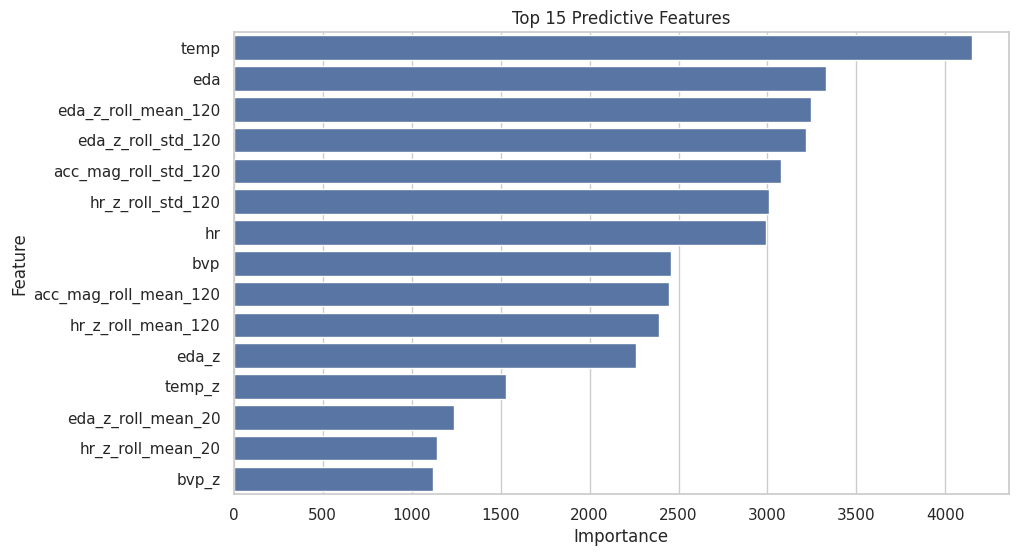

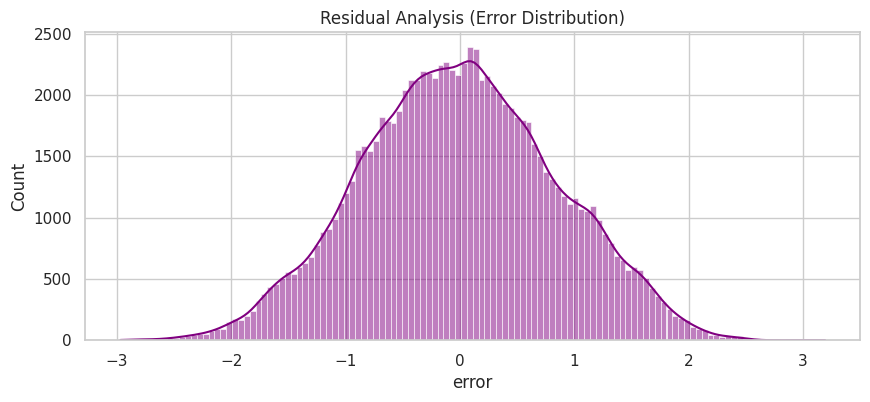

In [4]:
# 1. Feature Importance
importances = np.mean([m.feature_importances_ for m in models], axis=0)
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Predictive Features')
plt.show()

# 2. Residual Distribution
df['error'] = df[TARGET] - df['oof_preds']
plt.figure(figsize=(10, 4))
sns.histplot(df['error'], kde=True, color='purple')
plt.title('Residual Analysis (Error Distribution)')
plt.show()